<center><h1 style="margin-bottom: 0px;">Artificial Intelligence (25/26)</h1></center>
<center><h2 style="margin-top: 0px;">Decision Trees Applied to IRIS Dataset</h2></center>

#### <center> Joana Antunes (202405702), Sílvia Pinto (202405988) </center> <br>

#### **6. Analysis of IRIS Dataset using Decision Trees with ID3** <br>
<div style="text-align: justify;"><p style="text-indent: 2em;">Like it was asked in the guidelines of the project, we are now will now analyse the IRIS dataset as a warm-up. This dataset is composed by 150 samples of plants from three different classes: Iris setosa, Iris virginica and Iris versicolor. The attributes of each class are sepal length, sepal width, petal length and petal width.
<p style="text-indent: 2em;">These attributes are numerical values and ID3 requires categorical values. So, we need to discretise each attribute. We chose to do that using 3 intervals, in order to ensure that each interval contains a similar number of examples - this helps building trees with better performance:</div>

> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**LOW** *Values below the 33rd percentile;*

> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**MEDIUM** *Values between the 33rd and the 67th percentile;*

> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**HIGH** *Values above the 67th percentile.*
<div style="text-align: justify;"><p style="text-indent: 2em;">After discretisation, we divide the dataset into training set (80%) and test set (20%). For that, we use a fixed random seed, which garantees that the train and test split is always identical every time we run it, making our results reproducible. Then, we train the algorithm, calculate is accuracy and produce its confusion matrix.</div>

Train: 120 samples | Test: 30 samples
Accuracy on test set: 93.33%


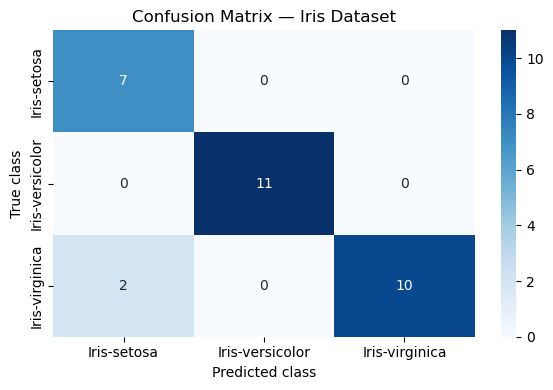

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
%run DecisionTrees.ipynb

df = pd.read_csv("iris.csv")
numeric_cols = ['sepallength', 'sepalwidth', 'petallength', 'petalwidth']

df_disc = df.copy() # Discretise numerical values into low/medium/high using quantiles
thresholds = {} 

for col in numeric_cols:
    q33 = df[col].quantile(0.33)
    q67 = df[col].quantile(0.67)
    thresholds[col] = (q33, q67)
    def discretize(val, low=q33, high=q67):
        if val <= low: return 'low'
        if val <= high: return 'medium'
        return 'high'
    df_disc[col] = df[col].apply(discretize)

np.random.seed(42)
idx = np.random.permutation(len(df_disc))
split = int(0.8 * len(idx))
train_idx, test_idx = idx[:split], idx[split:] # Train/test split (80/20)

train_data   = df_disc.iloc[train_idx][numeric_cols].to_dict(orient='records')
train_labels = df_disc.iloc[train_idx]['class'].tolist()
test_data    = df_disc.iloc[test_idx][numeric_cols].to_dict(orient='records')
test_labels  = df_disc.iloc[test_idx]['class'].tolist()

print(f"Train: {len(train_data)} samples | Test: {len(test_data)} samples")

tree_iris = id3(train_data, train_labels, set(numeric_cols), max_depth=6) # Train the tree

default = Counter(train_labels).most_common(1)[0][0]
predictions = [classify(tree_iris, s, default) for s in test_data]
accuracy = sum(p == t for p, t in zip(predictions, test_labels)) / len(test_labels) # Evaluate accuracy
print(f"Accuracy on test set: {accuracy:.2%}")

classes = sorted(set(test_labels))
n = len(classes)
matrix = np.zeros((n, n), dtype=int)
class_to_idx = {c: i for i, c in enumerate(classes)}
for true, pred in zip(test_labels, predictions):
    matrix[class_to_idx[true]][class_to_idx[pred]] += 1 # Compute confusion matrix
 

plt.figure(figsize=(6, 4))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.title('Confusion Matrix — Iris Dataset')
plt.tight_layout()
plt.show()

<div style="text-align: justify;"><p style="text-indent: 2em;">The resulting predictions of our Decision Tree algortihm with ID3 has an accuracy of 93.33%, which shows that it is working correctly. Observing the confusion matrix, we can make the following statements:</div>

> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**Iris Setosa** *All 7 examples were correctly classified. This is expected since setosa is linearly separable from the other two classes and is very easy to distinguish;*

> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**Iris Versicolor** *All 11 examples were correctly classified, showing the tree learned a reliable rule to identify this class;*

> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**Iris Virginica** *10 out of 12 examples were correctly classified. The 2 misclassified examples were predicted as Iris setosa, which is surprising since these two classes are usually well separated. This is likely a consequence of the discretisation — by grouping continuous values into only three intervals, some fine-grained distinctions between classes are lost, which can occasionally lead to misclassifications.*
<div style="text-align: justify;"><p style="text-indent: 2em;">The assigment also requires us to represent the tree visually. Therefore, we implement the fuctions "get_tree_depth" and "get_tree_width", that recursively calculate the dimensions of the tree. These will be used to automatically adjust the size of the figure. The function "draw_tree" is responsable for creating the visualization of the tree. At last, we have the function "visualize_tree" that calls draw_tree and allows us to view the tree created using the library matplotlib.</div>

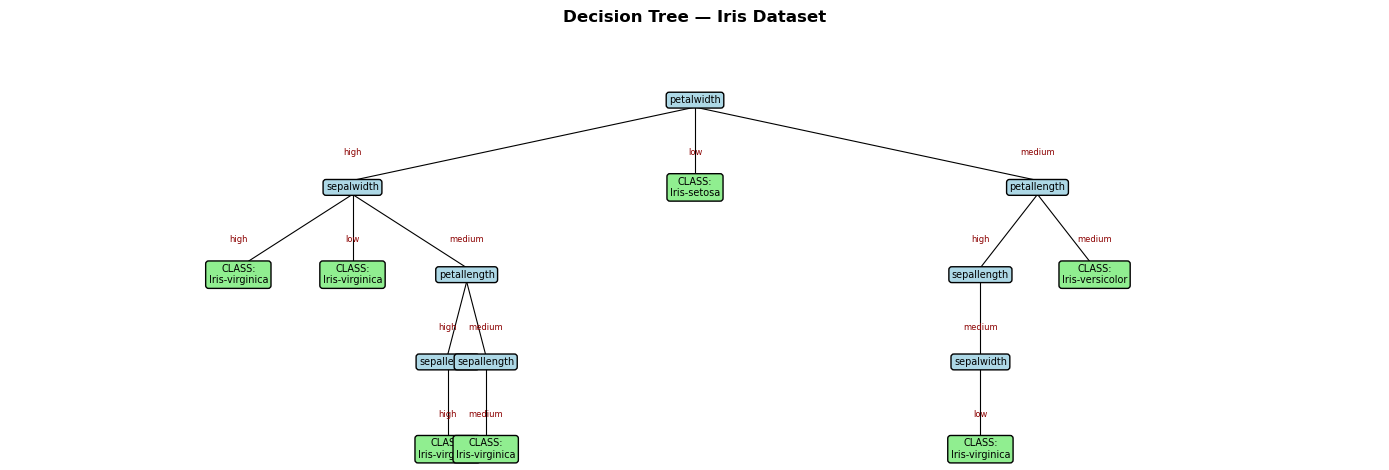

In [24]:
def get_tree_depth(node):
    if node.is_leaf(): return 0
    return 1 + max(get_tree_depth(child) for child in node.children.values())

def get_tree_width(node):
    if node.is_leaf(): return 1
    return sum(get_tree_width(child) for child in node.children.values())

def draw_tree(node, ax, x, y, x_offset, y_offset, branch_label=""): 
    if node.is_leaf(): 
        color = "lightgreen"
        text = f"CLASS:\n{node.label}"
    else:
        color = "lightblue"
        text = f"{node.attribute}"
    bbox = dict(boxstyle="round,pad=0.3", facecolor=color, edgecolor="black")
    ax.text(x, y, text, ha="center", va="center", fontsize=7, bbox=bbox, wrap=True)

    if branch_label: # Draw branch label
        ax.text(x, y + y_offset * 0.4, str(branch_label), ha="center", va="center", fontsize=6, color="darkred")

    if not node.is_leaf():
        children = sorted(node.children.items(), key=lambda x: str(x[0]))
        n = len(children)
        total_width = x_offset * (n - 1)
        start_x = x - total_width / 2
        for i, (val, child) in enumerate(children): # Draw line to child
            child_x = start_x + i * x_offset
            child_y = y - y_offset
            ax.plot([x, child_x], [y - 0.02, child_y + 0.02], color="black", linewidth=0.8)

            draw_tree(child, ax, child_x, child_y,
                      x_offset / max(n, 1.5), y_offset, val)


def visualize_tree(tree, title="Decision Tree"):
    depth = get_tree_depth(tree)
    width = get_tree_width(tree)
    fig_width = max(10, width * 2)
    fig_height = max(4, depth * 1.2)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 0.2)
    ax.axis("off")
    ax.set_title(title, fontsize=12, fontweight="bold")
    draw_tree(tree, ax, x=0, y=0, x_offset=0.5, y_offset=0.25)
    plt.tight_layout()
    plt.show()

visualize_tree(tree_iris, title="Decision Tree — Iris Dataset")